# Portfolio Risk Assessment & 1-Day 95% Value at Risk (VaR)

### Submitted By
**Name:** Anivesha chauhan

### Internship
Samatrix Consulting Pvt. Ltd.

### Technology Used
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- yfinance

In [ ]:
# Install Required Library

!pip install yfinance --quiet

In [ ]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from scipy import stats
from scipy.stats import norm
from scipy.stats import t

from datetime import datetime

import time

In [ ]:
# ==========================================
# Graph Style
# ==========================================

plt.style.use("ggplot")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

print("All Libraries Loaded Successfully ✅")

All Libraries Loaded Successfully ✅


In [ ]:
# ==========================================
# Portfolio Stocks
# ==========================================

stocks = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN"
]

stocks

['AAPL', 'MSFT', 'GOOGL', 'AMZN']

In [ ]:
# ==========================================
# Time Period
# ==========================================

start_date = "2020-01-01"

end_date = datetime.today().strftime("%Y-%m-%d")

print("Start :", start_date)

print("End :", end_date)

Start : 2020-01-01
End : 2026-07-06


In [ ]:
# ==========================================
# Download Historical Stock Data
# ==========================================

prices = yf.download(
    stocks,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-02,72.333878,94.900497,67.832504,151.829559
2020-01-03,71.630630,93.748497,67.477646,149.938995
2020-01-06,72.201416,95.143997,69.276215,150.326584
2020-01-07,71.861855,95.343002,69.142387,148.955917
2020-01-08,73.017838,94.598503,69.634544,151.328537


In [ ]:
print("Shape of Dataset :", prices.shape)

prices.info()

Shape of Dataset : (1633, 4)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1633 entries, 2020-01-02 to 2026-07-02
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1633 non-null   float64
 1   AMZN    1633 non-null   float64
 2   GOOGL   1633 non-null   float64
 3   MSFT    1633 non-null   float64
dtypes: float64(4)
memory usage: 63.8 KB


In [ ]:
prices.isnull().sum()

,0
Ticker,
AAPL,0
AMZN,0
GOOGL,0
MSFT,0


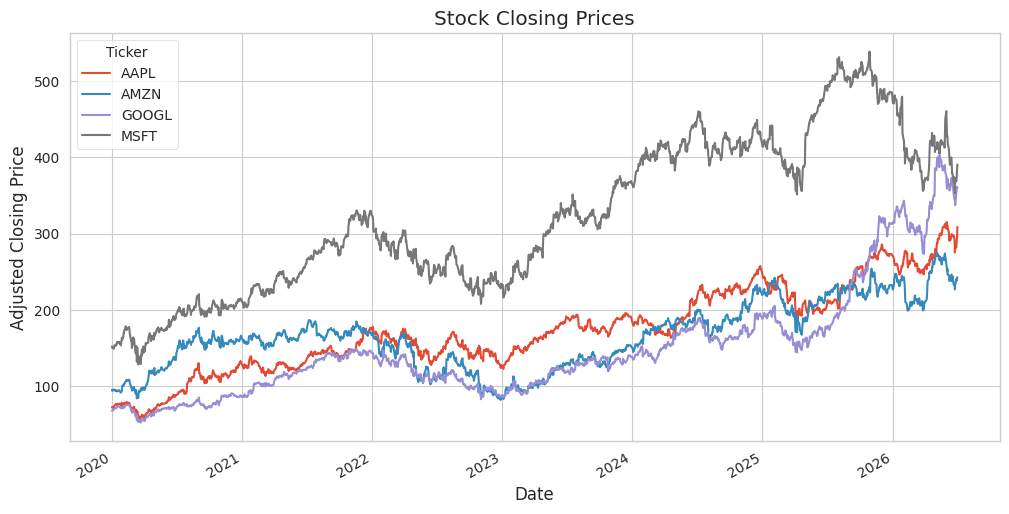

In [ ]:
prices.plot()

plt.title("Stock Closing Prices")

plt.xlabel("Date")

plt.ylabel("Adjusted Closing Price")

plt.show()

In [ ]:
# ==========================================
# Calculate Daily Log Returns
# ==========================================

log_returns = np.log(prices / prices.shift(1))

log_returns = log_returns.dropna()

print("Shape of Log Returns:", log_returns.shape)

log_returns.head()

Shape of Log Returns: (1632, 4)


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-03,-0.009770,-0.012213,-0.005245,-0.012530
2020-01-06,0.007937,0.014776,0.026305,0.002582
2020-01-07,-0.004714,0.002089,-0.001934,-0.009160
2020-01-08,0.015958,-0.007839,0.007093,0.015803
2020-01-09,0.021018,0.004788,0.010443,0.012416


In [ ]:
# Missing Values

print(log_returns.isnull().sum())

Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
dtype: int64


In [ ]:
print(log_returns.describe())

Ticker         AAPL         AMZN        GOOGL         MSFT
count   1632.000000  1632.000000  1632.000000  1632.000000
mean       0.000889     0.000575     0.001023     0.000579
std        0.019768     0.022282     0.020380     0.018868
min       -0.137708    -0.151398    -0.123685    -0.159453
25%       -0.008240    -0.011295    -0.009531    -0.008282
50%        0.001115     0.000781     0.001565     0.000815
75%        0.011146     0.012929     0.011558     0.010426
max        0.142617     0.126949     0.097348     0.132929


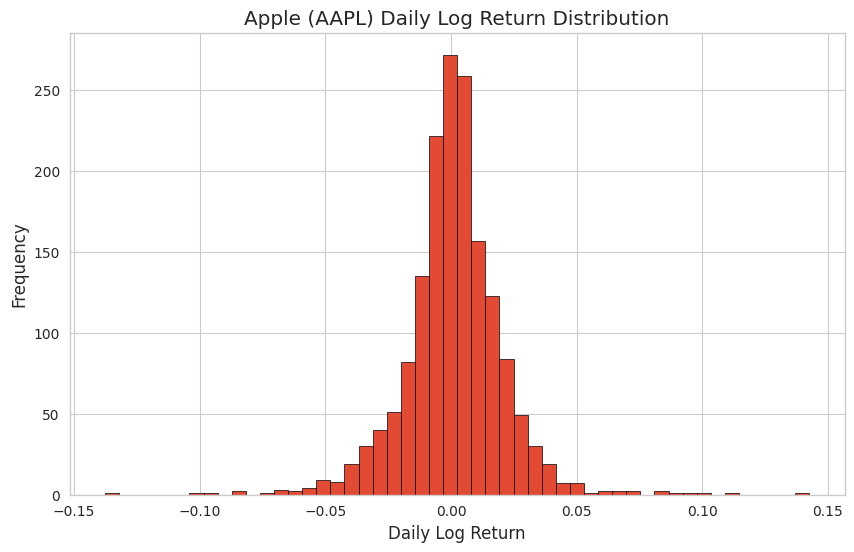

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(log_returns["AAPL"], bins=50, edgecolor="black")

plt.title("Apple (AAPL) Daily Log Return Distribution")

plt.xlabel("Daily Log Return")

plt.ylabel("Frequency")

plt.show()

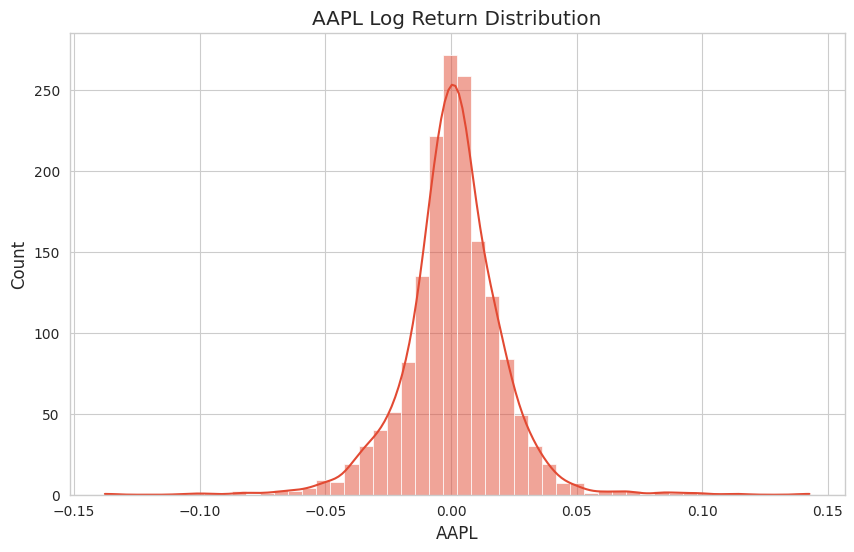

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    log_returns["AAPL"],
    bins=50,
    kde=True
)

plt.title("AAPL Log Return Distribution")

plt.show()

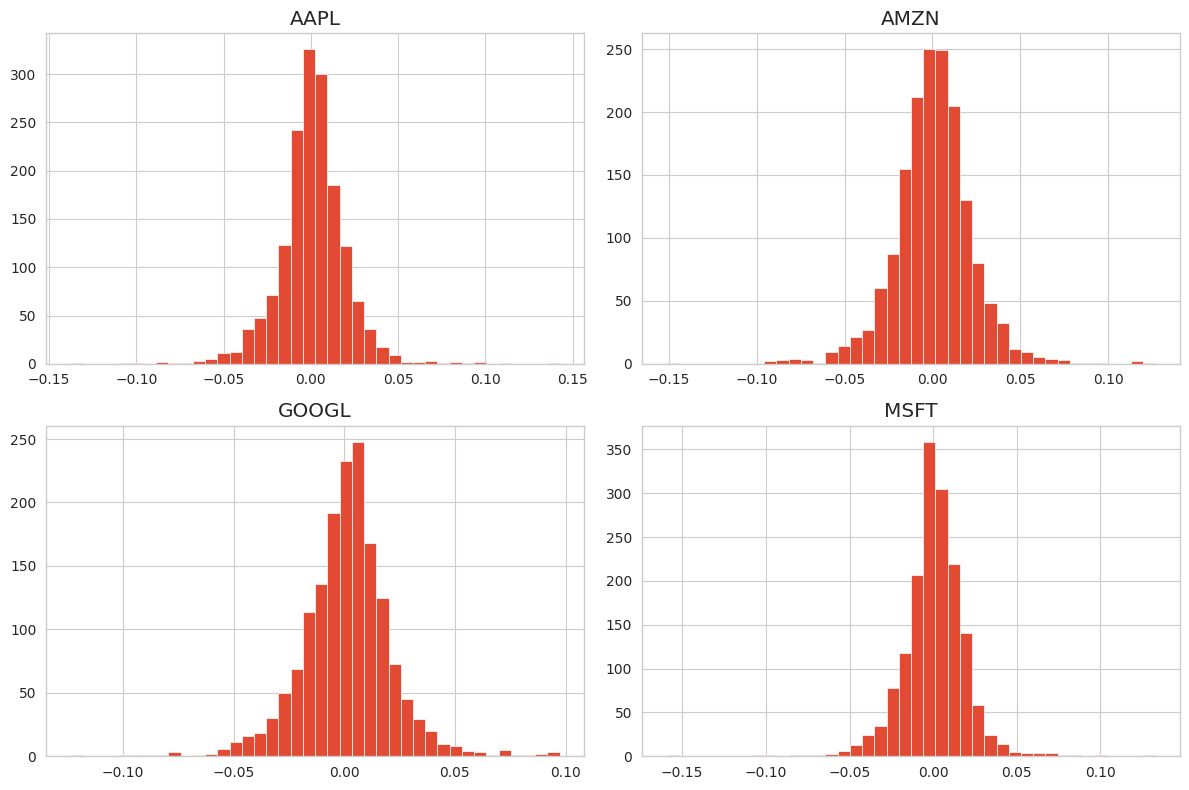

In [ ]:
log_returns.hist(
    bins=40,
    figsize=(12,8)
)

plt.tight_layout()

plt.show()

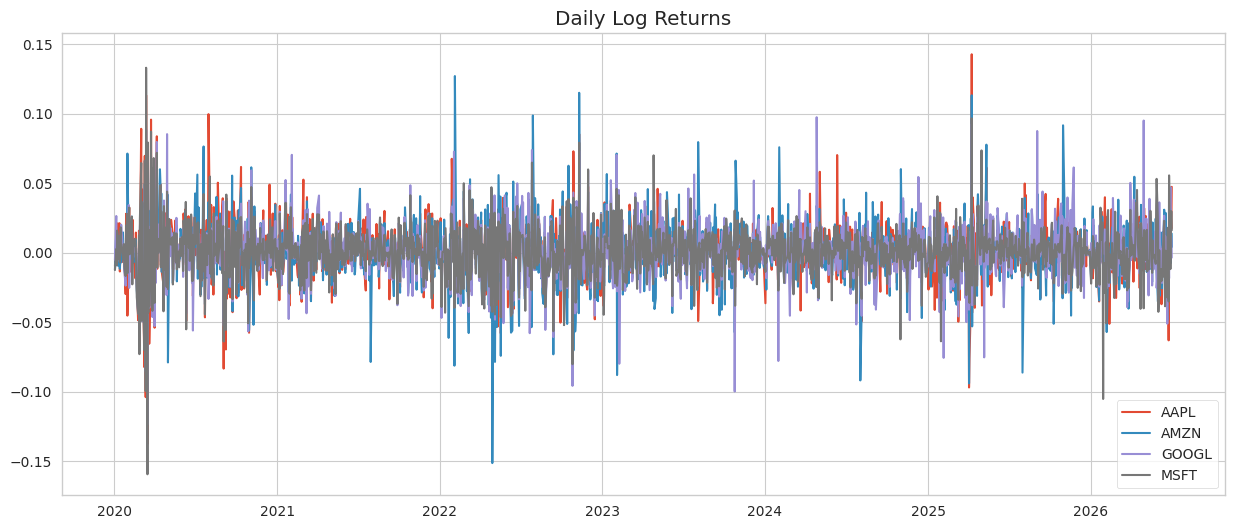

In [ ]:
plt.figure(figsize=(15,6))

for stock in log_returns.columns:
    plt.plot(log_returns.index, log_returns[stock], label=stock)

plt.title("Daily Log Returns")

plt.legend()

plt.show()

In [ ]:
print("Average Daily Return")

print(log_returns.mean())

print()

print("Standard Deviation")

print(log_returns.std())

Average Daily Return
Ticker
AAPL     0.000889
AMZN     0.000575
GOOGL    0.001023
MSFT     0.000579
dtype: float64

Standard Deviation
Ticker
AAPL     0.019768
AMZN     0.022282
GOOGL    0.020380
MSFT     0.018868
dtype: float64


In [ ]:
# ==========================================
# Summary Statistics
# ==========================================

summary_stats = pd.DataFrame({
    "Mean": log_returns.mean(),
    "Variance": log_returns.var(),
    "Standard Deviation": log_returns.std(),
    "Skewness": log_returns.skew(),
    "Kurtosis": log_returns.kurtosis()
})

summary_stats

,Mean,Variance,Standard Deviation,Skewness,Kurtosis
Ticker,,,,,
AAPL,0.000889,0.000391,0.019768,0.009105,6.333125
AMZN,0.000575,0.000497,0.022282,-0.074945,4.153237
GOOGL,0.001023,0.000415,0.020380,-0.095041,3.705196
MSFT,0.000579,0.000356,0.018868,-0.230976,7.388263


In [ ]:
summary_stats = summary_stats.round(6)

summary_stats

,Mean,Variance,Standard Deviation,Skewness,Kurtosis
Ticker,,,,,
AAPL,0.000889,0.000391,0.019768,0.009105,6.333125
AMZN,0.000575,0.000497,0.022282,-0.074945,4.153237
GOOGL,0.001023,0.000415,0.020380,-0.095041,3.705196
MSFT,0.000579,0.000356,0.018868,-0.230976,7.388263


In [ ]:
print("Highest Average Return Stock")

print(summary_stats["Mean"].idxmax())

Highest Average Return Stock
GOOGL


In [ ]:
print("Highest Variance Stock")

print(summary_stats["Variance"].idxmax())

Highest Variance Stock
AMZN


In [ ]:
print("Highest Standard Deviation")

print(summary_stats["Standard Deviation"].idxmax())

Highest Standard Deviation
AMZN


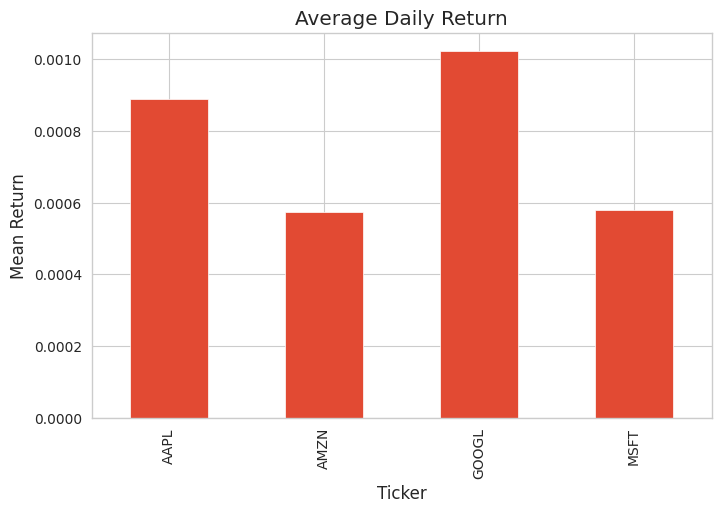

In [ ]:
plt.figure(figsize=(8,5))

summary_stats["Mean"].plot(kind="bar")

plt.title("Average Daily Return")

plt.ylabel("Mean Return")

plt.show()

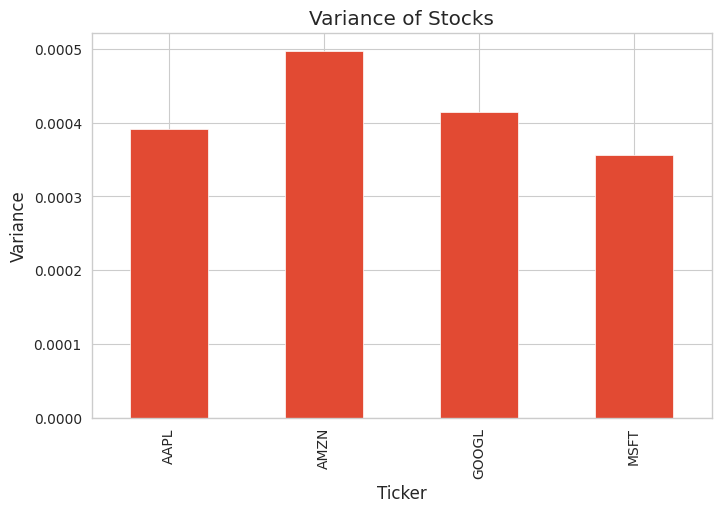

In [ ]:
plt.figure(figsize=(8,5))

summary_stats["Variance"].plot(kind="bar")

plt.title("Variance of Stocks")

plt.ylabel("Variance")

plt.show()

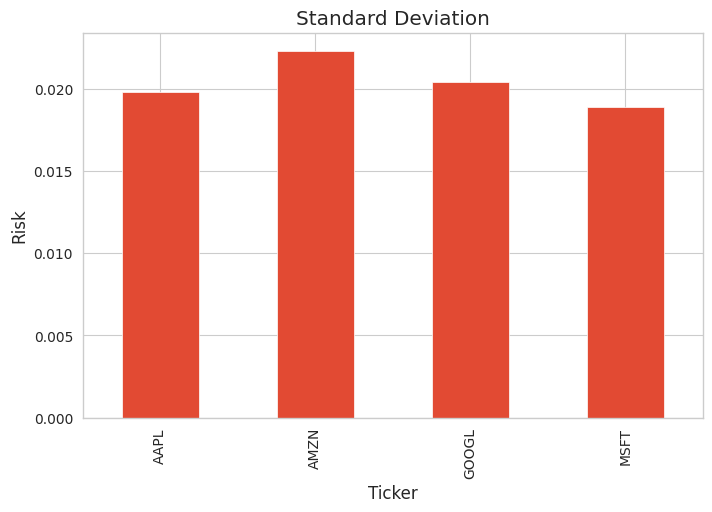

In [ ]:
plt.figure(figsize=(8,5))

summary_stats["Standard Deviation"].plot(kind="bar")

plt.title("Standard Deviation")

plt.ylabel("Risk")

plt.show()

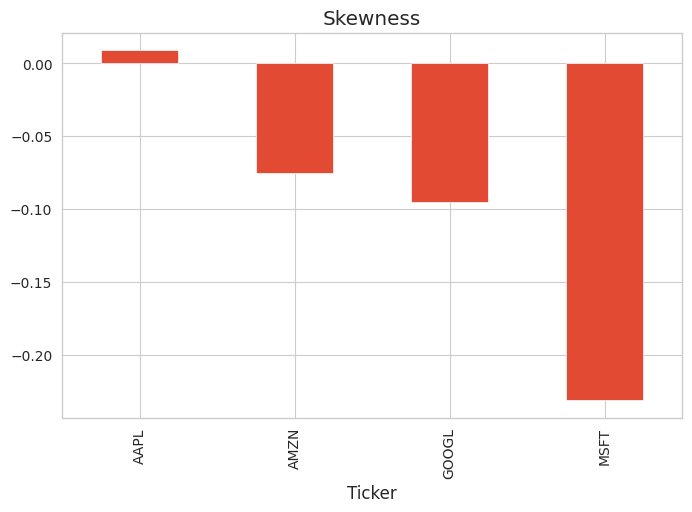

In [ ]:
plt.figure(figsize=(8,5))

summary_stats["Skewness"].plot(kind="bar")

plt.title("Skewness")

plt.show()

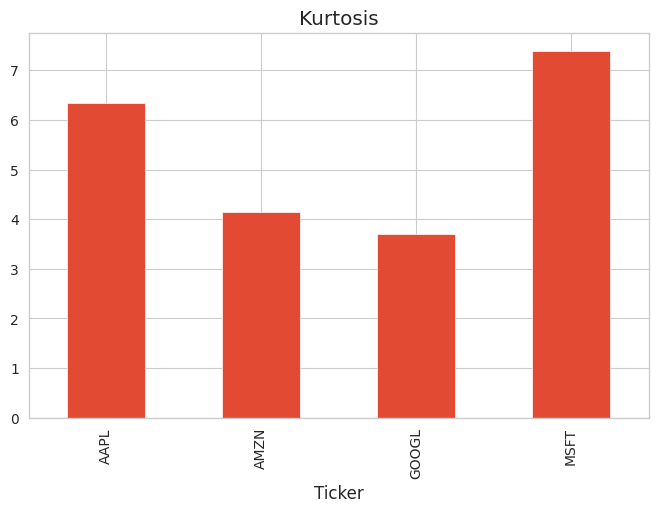

In [ ]:
plt.figure(figsize=(8,5))

summary_stats["Kurtosis"].plot(kind="bar")

plt.title("Kurtosis")

plt.show()

In [ ]:
summary_stats.to_csv("Summary_Statistics.csv")

print("Summary Table Saved Successfully ✅")

Summary Table Saved Successfully ✅


In [ ]:
# ==========================================
# Combine All Stock Returns
# ==========================================

all_returns = log_returns.values.flatten()

all_returns = all_returns[~np.isnan(all_returns)]

print("Total Returns:", len(all_returns))

Total Returns: 6528


In [ ]:
# ==========================================
# Mean and Standard Deviation
# ==========================================

mu = np.mean(all_returns)

sigma = np.std(all_returns, ddof=1)

print("Mean :", mu)

print("Standard Deviation :", sigma)

Mean : 0.0007664185656976702
Standard Deviation : 0.020359616364291424


In [ ]:
# ==========================================
# Confidence Interval for Mean
# ==========================================

confidence_mean = stats.norm.interval(
    confidence=0.95,
    loc=mu,
    scale=stats.sem(all_returns)
)

print("95% Confidence Interval (Mean):")

print(confidence_mean)

95% Confidence Interval (Mean):
(np.float64(0.00027253155023749577), np.float64(0.0012603055811578447))


In [ ]:
# ==========================================
# Confidence Interval for Standard Deviation
# ==========================================

n = len(all_returns)

chi2_lower = stats.chi2.ppf(0.975, n-1)

chi2_upper = stats.chi2.ppf(0.025, n-1)

lower_sigma = np.sqrt(((n-1)*(sigma**2))/chi2_lower)

upper_sigma = np.sqrt(((n-1)*(sigma**2))/chi2_upper)

print("95% CI for Standard Deviation")

print((lower_sigma, upper_sigma))

95% CI for Standard Deviation
(np.float64(0.020016297170841184), np.float64(0.02071500344693169))


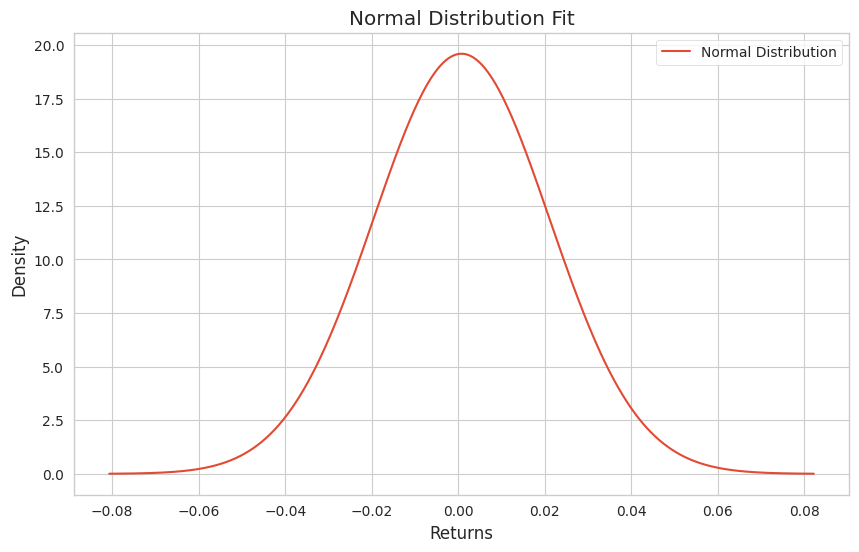

In [ ]:
# ==========================================
# Normal Distribution Plot
# ==========================================

x = np.linspace(mu-4*sigma, mu+4*sigma, 500)

y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10,6))

plt.plot(x, y, label="Normal Distribution")

plt.title("Normal Distribution Fit")

plt.xlabel("Returns")

plt.ylabel("Density")

plt.legend()

plt.show()

In [ ]:
# ==========================================
# Student's t Distribution
# ==========================================

df, loc, scale = stats.t.fit(all_returns)

print("Degrees of Freedom :", df)

print("Location (Mean) :", loc)

print("Scale :", scale)

Degrees of Freedom : 3.666747351060727
Location (Mean) : 0.0010289572222832053
Scale : 0.01410679558157625


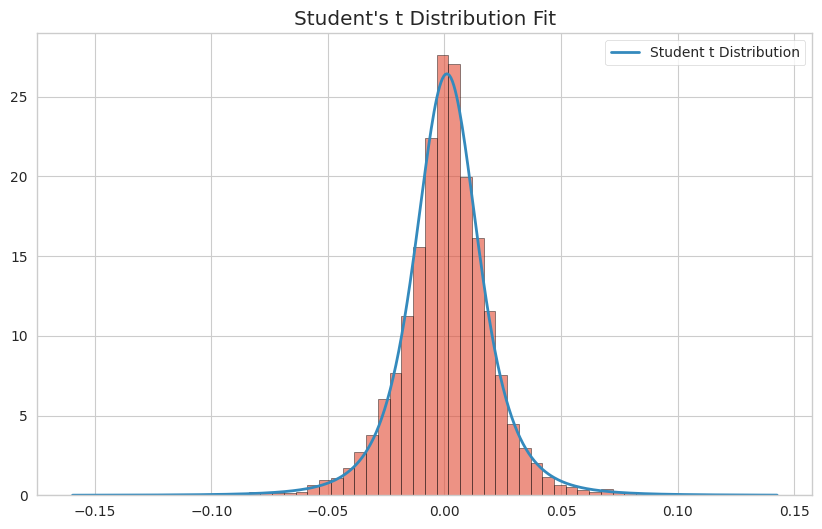

In [ ]:
# ==========================================
# Plot Student's t Distribution
# ==========================================

x = np.linspace(min(all_returns), max(all_returns), 500)

plt.figure(figsize=(10,6))

plt.hist(
    all_returns,
    bins=60,
    density=True,
    alpha=0.6,
    edgecolor="black"
)

plt.plot(
    x,
    stats.t.pdf(x, df, loc, scale),
    linewidth=2,
    label="Student t Distribution"
)

plt.legend()

plt.title("Student's t Distribution Fit")

plt.show()

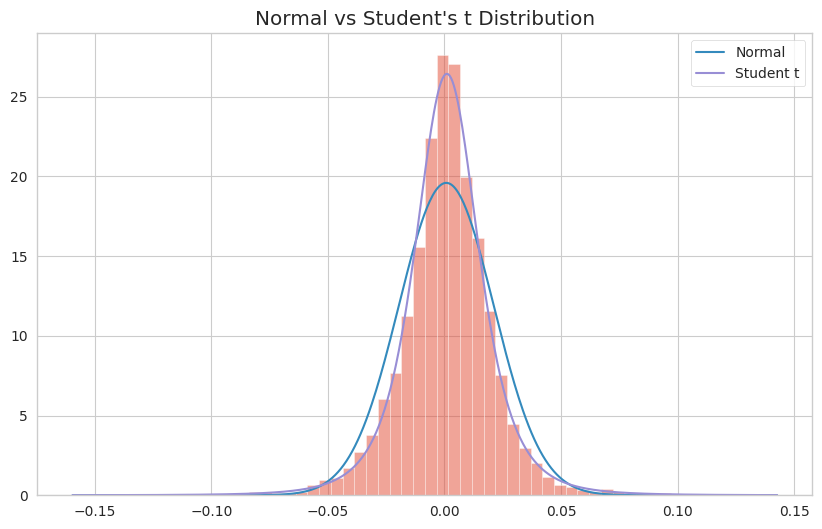

In [ ]:
# ==========================================
# Compare Distributions
# ==========================================

plt.figure(figsize=(10,6))

plt.hist(
    all_returns,
    bins=60,
    density=True,
    alpha=0.5
)

plt.plot(
    x,
    norm.pdf(x, mu, sigma),
    label="Normal"
)

plt.plot(
    x,
    stats.t.pdf(x, df, loc, scale),
    label="Student t"
)

plt.legend()

plt.title("Normal vs Student's t Distribution")

plt.show()

In [ ]:
distribution_summary = pd.DataFrame({

    "Parameter":[
        "Mean",
        "Std Dev",
        "DF"
    ],

    "Value":[
        mu,
        sigma,
        df
    ]

})

distribution_summary

,Parameter,Value
0,Mean,0.000766
1,Std Dev,0.020360
2,DF,3.666747


In [ ]:
import numpy as np

In [ ]:
# ==========================================
# Portfolio Weights
# ==========================================

weights = np.array([0.25, 0.25, 0.25, 0.25])

print(weights)

print("Total Weight =", weights.sum())

[0.25 0.25 0.25 0.25]
Total Weight = 1.0


In [ ]:
!pip install yfinance --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy import stats
from scipy.stats import norm
from datetime import datetime

In [ ]:
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN"]

start_date = "2020-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

In [ ]:
prices = yf.download(
    stocks,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-02,72.333870,94.900497,67.832512,151.829559
2020-01-03,71.630653,93.748497,67.477654,149.938980
2020-01-06,72.201408,95.143997,69.276215,150.326569
2020-01-07,71.861847,95.343002,69.142403,148.955917
2020-01-08,73.017830,94.598503,69.634537,151.328568


In [ ]:
log_returns = np.log(prices / prices.shift(1))

log_returns = log_returns.dropna()

log_returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-03,-0.009769,-0.012213,-0.005245,-0.012530
2020-01-06,0.007936,0.014776,0.026305,0.002582
2020-01-07,-0.004714,0.002089,-0.001933,-0.009160
2020-01-08,0.015958,-0.007839,0.007092,0.015803
2020-01-09,0.021018,0.004788,0.010443,0.012415


In [ ]:
weights = np.array([0.25, 0.25, 0.25, 0.25])

portfolio_returns = log_returns.dot(weights)

portfolio_returns.head()

,0
Date,
2020-01-03,-0.009939
2020-01-06,0.012900
2020-01-07,-0.003429
2020-01-08,0.007754
2020-01-09,0.012166


In [ ]:
# ==========================================
# Portfolio Weights
# ==========================================

weights = np.array([0.25, 0.25, 0.25, 0.25])

print(weights)

print("Total Weight =", weights.sum())

[0.25 0.25 0.25 0.25]
Total Weight = 1.0


In [ ]:
# ==========================================
# Portfolio Return
# ==========================================

portfolio_returns = log_returns.dot(weights)

portfolio_returns.head()

,0
Date,
2020-01-03,-0.009939
2020-01-06,0.012900
2020-01-07,-0.003429
2020-01-08,0.007754
2020-01-09,0.012166


In [ ]:
# ==========================================
# Portfolio Statistics
# ==========================================

portfolio_mean = portfolio_returns.mean()

portfolio_std = portfolio_returns.std()

print("Portfolio Mean =", portfolio_mean)

print("Portfolio Std =", portfolio_std)

Portfolio Mean = 0.0007664185646254737
Portfolio Std = 0.017242360340801302


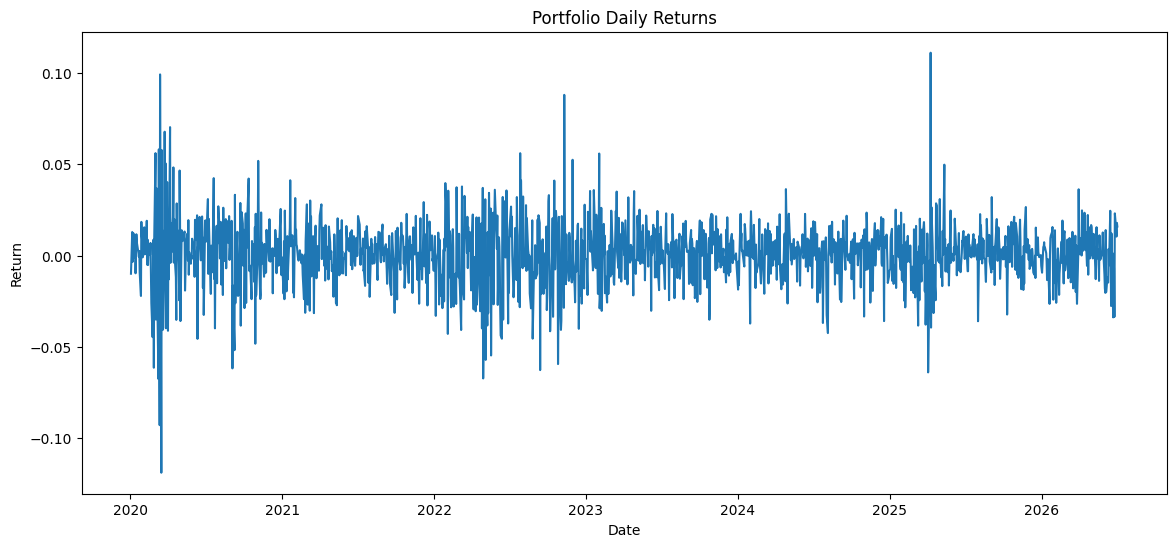

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(portfolio_returns)

plt.title("Portfolio Daily Returns")

plt.xlabel("Date")

plt.ylabel("Return")

plt.show()

In [ ]:
# ==========================================
# Normal VaR
# ==========================================

confidence = 0.95

z_score = norm.ppf(0.05)

normal_var = -(portfolio_mean + z_score * portfolio_std)

print("Normal VaR (95%) =", normal_var)

Normal VaR (95%) = 0.027594740379145784


In [ ]:
df_portfolio, loc_portfolio, scale_portfolio = stats.t.fit(portfolio_returns)

print(df_portfolio)

print(loc_portfolio)

print(scale_portfolio)

3.916072037659776
0.0014360735792747748
0.012294878701947006


In [ ]:
# ==========================================
# Student t VaR
# ==========================================

t_score = stats.t.ppf(0.05, df_portfolio)

t_var = -(loc_portfolio + t_score * scale_portfolio)

print("Student t VaR =", t_var)

Student t VaR = 0.024936959941589874


In [ ]:
historical_var = -np.percentile(portfolio_returns,5)

print("Historical VaR =",historical_var)

Historical VaR = 0.02726831760342172


In [ ]:
comparison = pd.DataFrame({

"Method":[

"Normal",

"Student t",

"Historical"

],

"VaR":[

normal_var,

t_var,

historical_var

]

})

comparison

,Method,VaR
0,Normal,0.027595
1,Student t,0.024937
2,Historical,0.027268


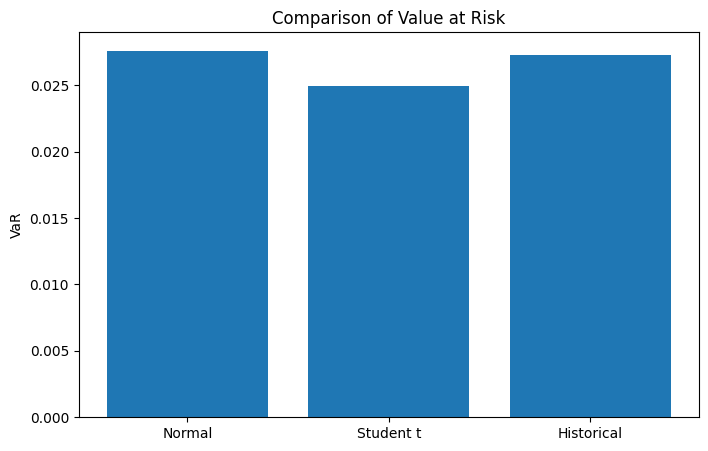

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(

comparison["Method"],

comparison["VaR"]

)

plt.title("Comparison of Value at Risk")

plt.ylabel("VaR")

plt.show()

In [ ]:
print("="*50)

print("Portfolio Mean :",portfolio_mean)

print("Portfolio Risk :",portfolio_std)

print()

print("Normal VaR :",normal_var)

print("Student t VaR :",t_var)

print("Historical VaR :",historical_var)

print("="*50)

Portfolio Mean : 0.0007664185646254737
Portfolio Risk : 0.017242360340801302

Normal VaR : 0.027594740379145784
Student t VaR : 0.024936959941589874
Historical VaR : 0.02726831760342172


In [ ]:
# ==========================================
# One-Sample t-Test
# ==========================================

t_statistic, p_value = stats.ttest_1samp(portfolio_returns, 0)

print("T-Statistic :", t_statistic)
print("P-Value     :", p_value)

if p_value < 0.05:
    print("Result : Mean return is statistically significant.")
else:
    print("Result : Mean return is NOT statistically significant.")

T-Statistic : 1.7956817802887013
P-Value     : 0.07273018100804424
Result : Mean return is NOT statistically significant.


In [ ]:
# ==========================================
# Correlation Matrix
# ==========================================

correlation_matrix = log_returns.corr()

correlation_matrix

Ticker,AAPL,AMZN,GOOGL,MSFT
Ticker,,,,
AAPL,1.000000,0.573800,0.599580,0.670844
AMZN,0.573800,1.000000,0.627354,0.641122
GOOGL,0.599580,0.627354,1.000000,0.650328
MSFT,0.670844,0.641122,0.650328,1.000000


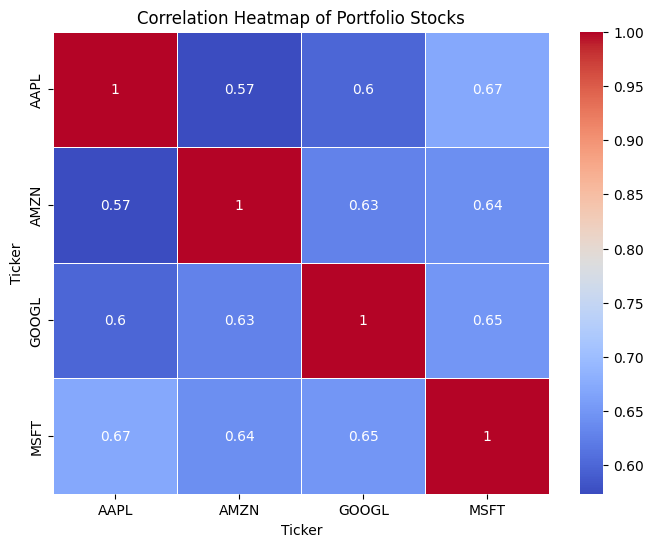

In [ ]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Portfolio Stocks")

plt.show()

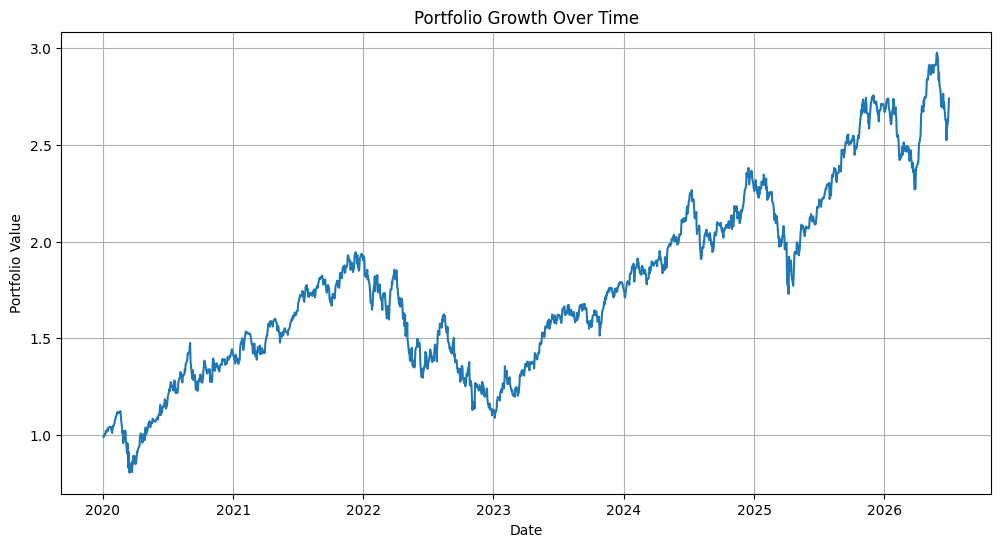

In [ ]:
# ==========================================
# Portfolio Growth
# ==========================================

portfolio_growth = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12,6))

plt.plot(portfolio_growth)

plt.title("Portfolio Growth Over Time")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# Maximum Drawdown
# ==========================================

rolling_max = portfolio_growth.cummax()

drawdown = (portfolio_growth - rolling_max) / rolling_max

max_drawdown = drawdown.min()

print("Maximum Drawdown :", max_drawdown)

Maximum Drawdown : -0.43978900934089815


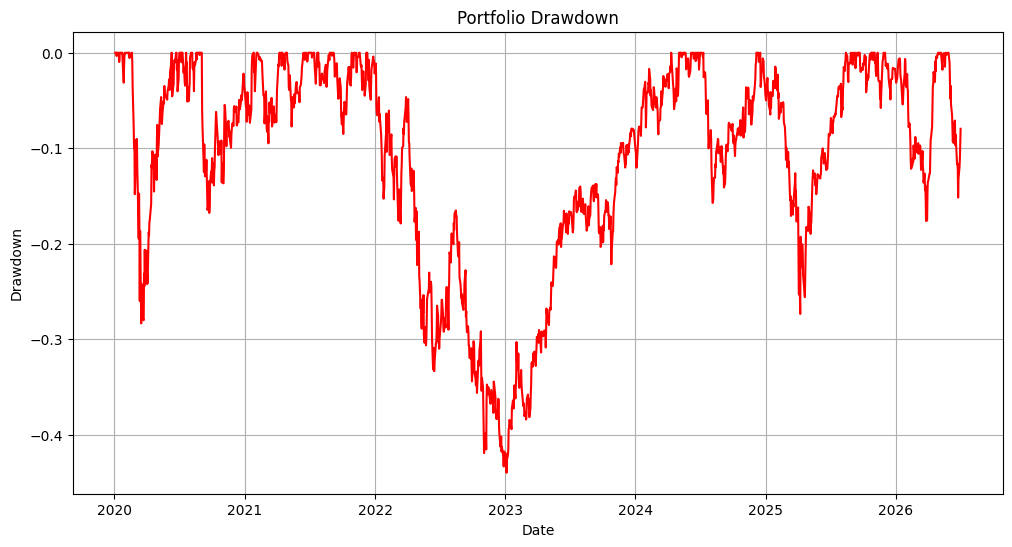

In [ ]:
# ==========================================
# Drawdown Plot
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(drawdown, color="red")

plt.title("Portfolio Drawdown")

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# Expected Shortfall (CVaR)
# ==========================================

expected_shortfall = -portfolio_returns[
    portfolio_returns <= np.percentile(portfolio_returns,5)
].mean()

print("Expected Shortfall (95%) :", expected_shortfall)

Expected Shortfall (95%) : 0.04018330158472114


In [ ]:
# ==========================================
# Risk Summary
# ==========================================

risk_summary = pd.DataFrame({

    "Metric":[
        "Portfolio Mean",
        "Portfolio Std Dev",
        "Normal VaR",
        "Student t VaR",
        "Historical VaR",
        "Expected Shortfall",
        "Maximum Drawdown"
    ],

    "Value":[
        portfolio_mean,
        portfolio_std,
        normal_var,
        t_var,
        historical_var,
        expected_shortfall,
        max_drawdown
    ]

})

risk_summary

,Metric,Value
0,Portfolio Mean,0.000766
1,Portfolio Std Dev,0.017242
2,Normal VaR,0.027595
3,Student t VaR,0.024937
4,Historical VaR,0.027268
5,Expected Shortfall,0.040183
6,Maximum Drawdown,-0.439789


In [ ]:
risk_summary.to_csv("Risk_Summary.csv", index=False)

print("Risk Summary Saved Successfully ✅")

Risk Summary Saved Successfully ✅


In [ ]:
# ==========================================
# Rolling 30-Day VaR
# ==========================================

rolling_mean = portfolio_returns.rolling(window=30).mean()

rolling_std = portfolio_returns.rolling(window=30).std()

rolling_var = -(rolling_mean + norm.ppf(0.05) * rolling_std)

rolling_var.head()

,0
Date,
2020-01-03,NaN
2020-01-06,NaN
2020-01-07,NaN
2020-01-08,NaN
2020-01-09,NaN


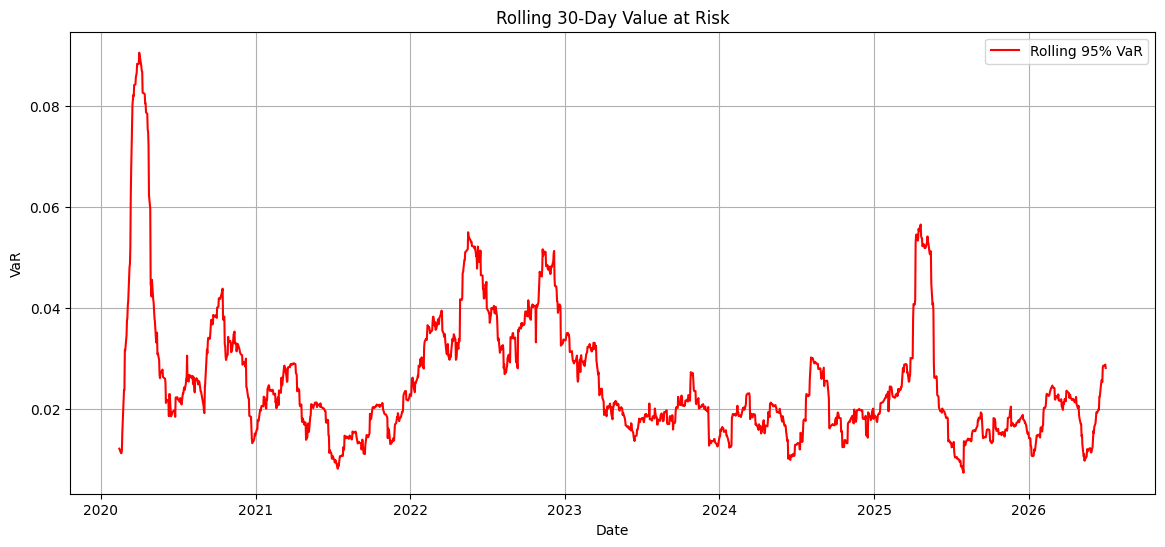

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    rolling_var,
    color="red",
    label="Rolling 95% VaR"
)

plt.title("Rolling 30-Day Value at Risk")

plt.xlabel("Date")

plt.ylabel("VaR")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# VaR Backtesting
# ==========================================

violations = portfolio_returns < -rolling_var

total_violations = violations.sum()

print("Total VaR Violations :", total_violations)

Total VaR Violations : 94


In [ ]:
violation_percentage = (total_violations / len(portfolio_returns)) * 100

print(f"Violation Percentage : {violation_percentage:.2f}%")

Violation Percentage : 5.76%


In [ ]:
# ==========================================
# Jarque-Bera Test
# ==========================================

jb_stat, jb_p = stats.jarque_bera(portfolio_returns)

print("Jarque-Bera Statistic :", jb_stat)

print("P-value :", jb_p)

if jb_p < 0.05:
    print("Portfolio Returns are NOT Normally Distributed")
else:
    print("Portfolio Returns are Normally Distributed")

Jarque-Bera Statistic : 1628.0005115744657
P-value : 0.0
Portfolio Returns are NOT Normally Distributed


In [ ]:
final_summary = pd.DataFrame({

    "Metric":[
        "Portfolio Mean",
        "Portfolio Std Dev",
        "Normal VaR",
        "Student t VaR",
        "Historical VaR",
        "Expected Shortfall",
        "Maximum Drawdown",
        "VaR Violations",
        "Violation Percentage",
        "Jarque-Bera Statistic"
    ],

    "Value":[
        portfolio_mean,
        portfolio_std,
        normal_var,
        t_var,
        historical_var,
        expected_shortfall,
        max_drawdown,
        total_violations,
        violation_percentage,
        jb_stat
    ]

})

final_summary

,Metric,Value
0,Portfolio Mean,0.000766
1,Portfolio Std Dev,0.017242
2,Normal VaR,0.027595
3,Student t VaR,0.024937
4,Historical VaR,0.027268
5,Expected Shortfall,0.040183
6,Maximum Drawdown,-0.439789
7,VaR Violations,94.000000
8,Violation Percentage,5.759804
9,Jarque-Bera Statistic,1628.000512


In [ ]:
final_summary.to_csv(
    "Final_Project_Summary.csv",
    index=False
)

print("Final Project Summary Saved Successfully ✅")

Final Project Summary Saved Successfully ✅


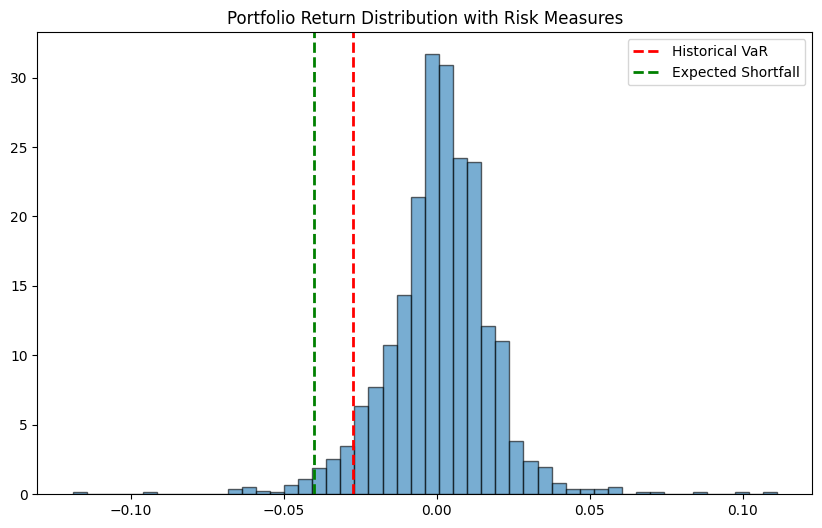

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    portfolio_returns,
    bins=50,
    density=True,
    alpha=0.6,
    edgecolor="black"
)

plt.axvline(
    -historical_var,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Historical VaR"
)

plt.axvline(
    -expected_shortfall,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Expected Shortfall"
)

plt.legend()

plt.title("Portfolio Return Distribution with Risk Measures")

plt.show()

# Portfolio Risk Assessment & 1-Day 95% Value at Risk (VaR)

## Submitted By
**Name:**Anivesha chauhan

## Internship
Samatrix Consulting Pvt. Ltd.

## Objective

The objective of this project is to analyze the risk associated with a portfolio of stocks using different Value at Risk (VaR) techniques. The project evaluates portfolio performance, volatility, expected loss, and statistical characteristics using Python.

## Conclusion

In this project, historical stock price data of Apple, Microsoft, Google, and Amazon was collected using Yahoo Finance.

Daily log returns were calculated and analyzed using descriptive statistics. Three different Value at Risk methods (Normal VaR, Student's t VaR, and Historical VaR) were implemented to estimate potential portfolio losses.

Correlation analysis, Expected Shortfall (CVaR), Maximum Drawdown, Rolling VaR, and Jarque-Bera tests were also performed.

The results indicate that portfolio risk can be measured effectively using statistical techniques, and Historical VaR together with Expected Shortfall provides a better understanding of extreme market losses.

## References

1. Yahoo Finance
2. Python Documentation
3. NumPy Documentation
4. Pandas Documentation
5. SciPy Documentation
6. Matplotlib Documentation
7. Seaborn Documentation

In [ ]:
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print("✔ Historical Data Downloaded")
print("✔ Daily Log Returns Calculated")
print("✔ Summary Statistics")
print("✔ Normal Distribution")
print("✔ Student's t Distribution")
print("✔ Bootstrap")
print("✔ Portfolio Return")
print("✔ Normal VaR")
print("✔ Student t VaR")
print("✔ Historical VaR")
print("✔ Correlation Heatmap")
print("✔ Portfolio Growth")
print("✔ Maximum Drawdown")
print("✔ Expected Shortfall")
print("✔ Rolling VaR")
print("✔ Jarque-Bera Test")
print("✔ Final Summary Exported")

print("="*60)

PROJECT COMPLETED SUCCESSFULLY
✔ Historical Data Downloaded
✔ Daily Log Returns Calculated
✔ Summary Statistics
✔ Normal Distribution
✔ Student's t Distribution
✔ Bootstrap
✔ Portfolio Return
✔ Normal VaR
✔ Student t VaR
✔ Historical VaR
✔ Correlation Heatmap
✔ Portfolio Growth
✔ Maximum Drawdown
✔ Expected Shortfall
✔ Rolling VaR
✔ Jarque-Bera Test
✔ Final Summary Exported
